#  Python Foundations Workshop 
 
**Audience:** AIMS Students
**Prerequisites:** Basic programming experience in any language

---

## What We'll Cover

| # | Topic | Key Concepts |
|---|-------|-------------|
| 1 | **Functions** | Parameters, `*args`/`**kwargs`, higher-order functions, closures |
| 2 | **Classes & OOP** | Encapsulation, inheritance, dunder methods, dataclasses |
| 3 | **Abstraction** | Abstract base classes, interfaces, SOLID principles |
| 4 | **Recursion** | Factorial, Fibonacci, tree traversal, memoization |
| 5 | **Decorators & Generators** | `@decorator` syntax, `yield`, lazy evaluation |
| 6 | **Plotting & Visualization** | Matplotlib, Seaborn, animations, interactive plots |

>  **Trial questions** are sprinkled throughout, attempt them before peeking at the solutions!

---

In [1]:
# Run this cell to make sure everything is installed
import sys
print(f"Python version: {sys.version}")


import warnings
warnings.filterwarnings('ignore')
print("Ready to go!")

Python version: 3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]
Ready to go!


---
# Module 1: Functions as Building Blocks of Clean Code

Functions encapsulate logic, promote reuse, and make programs readable.  
In Python, functions are **first-class objects**, thus, they can be passed around like any other value.

## 1.1 Basic Function Anatomy

In [ ]:
#Exercise: Create your functions that greets Bright if
#you are happy and does not if you are sad


def greet_me(name:str, moment:bool=True)->str:
    greetings = f"Hello {name}"
    if moment:
        return greetings
    else:
        return None

In [104]:
def greet(name: str, enthusiastic: bool = False) -> str:
    
    """Return a greeting string. Supports optional enthusiasm."""
    
    greeting = f"Hello, {name}!"
    
    if enthusiastic:
        greeting = greeting.upper()
    return greeting

# Type hints (name: str, -> str) are NOT enforced at runtime,
# but serve as documentation and help IDEs & tools like mypy.

In [4]:
print(greet("Nana"))
print(greet("Bob", enthusiastic=True))

Hello, Nana!
HELLO, BOB!


In [109]:
"Hello Brig i ght".split("i g")

['Hello Brig ', 'ht']

In [31]:
greet?

Signature: greet(name: str, enthusiastic: bool = False) -> str
Docstring: Return a greeting string. Supports optional enthusiasm.
File:      c:\users\bright\appdata\local\temp\ipykernel_10772\815078800.py
Type:      function

## 1.2 `*args` and `**kwargs` — Flexible Signatures

These let your function accept **any number** of positional or keyword arguments.

In [112]:
def smart_eamiling(g_type: str, level: str, *messages, **user_info):
    
    """A flexible logger that accepts any number of messages and user_info.
    
    g_type: A greetings string.
    level: The level of recipient.
    message: Allows you to pass any number of messages to the recipient.
    user_inf: Details of the targeted recipient
    """


    prefix = {"Tutor": "Bright", "Student": "Pearl", "Director": "Prof. Blaise"}.get(level, "Unknwon")

    greetings = g_type +" "+ prefix + ","
    
    combined = " ".join(messages)
    
    extras = ", ".join(f"{k}={v}" for k, v in user_info.items())
    
    print(f" {greetings} \n {combined} \n Details: {extras} \n")


In [118]:
prefix = {"Tutor": "Bright", "Student": "Pearl", "Director": "Prof. Blaise"}# 
prefix["a"]

KeyError: 'a'

In [127]:
def info_greet(g_type: str, level: str, *messages, **user_info):
    print(f"{g_type} {level} {messages} {user_info}")

In [128]:
info_greet("Hi", "Tutor", "Where have you been?", "I have been looking for you.", TID="Tutor1", Room=123)

Hi Tutor ('Where have you been?', 'I have been looking for you.') {'TID': 'Tutor1', 'Room': 123}


In [125]:
my_fruits = ["mango","Bannana","Orange"]
fruit_join = " ".join(my_fruits)
print(fruit_join)

mango Bannana Orange


In [111]:
smart_eamiling?

Signature: smart_eamiling(g_type: str, level: str, *messages, **user_info)
Docstring:
A flexible logger that accepts any number of messages and user_info.

g_type: A greetings string.
level: The level of recipient.
message: Allows you to pass any number of messages to the recipient.
user_inf: Details of the targeted recipient
File:      c:\users\bright\appdata\local\temp\ipykernel_14344\4277445096.py
Type:      function

In [28]:
smart_eamiling("Hi", "Tutor", "Where have you been?", "I have been looking for you.", TID="Tutor1", Room=123)

smart_eamiling( "Hello", "Student", "Can you see me at the office?", SID="S123")

 Hi Bright, 
 Where have you been? I have been looking for you. 
 Details: TID=Tutor1, Room=123 

 Hello Pearl, 
 Can you see me at the office? 
 Details: SID=S123 



In [34]:
help(smart_eamiling)

Help on function smart_eamiling in module __main__:

smart_eamiling(g_type: str, level: str, *messages, **user_info)
    A flexible logger that accepts any number of messages and user_info.
    
    g_type: A greetings string.
    level: The level of recipient.
    message: Allows you to pass any number of messages to the recipient.
    user_inf: Details of the targeted recipient



## 1.3 Higher-Order Functions

A **higher-order function** either takes a function as an argument or returns one.

In [102]:
from typing import Callable

def apply_twice(func: Callable[[int], int], value: int) -> int:
    
    """Apply a function twice to a value."""
    
    return func(func(value))

# Lambda expressions — anonymous one-line functions

square = lambda x: x ** 2
add_ten = lambda x: x + 10


In [36]:
print(f"apply_twice(square, 3) = {apply_twice(square, 3)}")     # square(9) = 81
print(f"apply_twice(add_ten, 5) = {apply_twice(add_ten, 5)}")   # add_ten(15) = 25

apply_twice(square, 3) = 81
apply_twice(add_ten, 5) = 25


In [103]:
Callable?

Signature:       Callable(*args, **kwargs)
Type:            _CallableType
String form:     typing.Callable
File:            c:\programdata\anaconda3\lib\typing.py
Docstring:      
Deprecated alias to collections.abc.Callable.

Callable[[int], str] signifies a function that takes a single
parameter of type int and returns a str.

The subscription syntax must always be used with exactly two
values: the argument list and the return type.
The argument list must be a list of types, a ParamSpec,
Concatenate or ellipsis. The return type must be a single type.

There is no syntax to indicate optional or keyword arguments;
such function types are rarely used as callback types.
Class docstring:
Mixin to prevent iteration, without being compatible with Iterable.

That is, we could do::

    def __iter__(self): raise TypeError()

But this would make users of this mixin duck type-compatible with
collections.abc.Iterable - isinstance(foo, Iterable) would be True.

Luckily, we can instead prevent ite

## 1.4 Closures, Functions That Remember

A **closure** is a function that captures variables from its enclosing scope.

In [37]:
def make_multiplier(factor: int):
    
    """Returns a function that multiplies its input by `factor`."""
    
    def multiplier(x):
        return x * factor   # `factor` is captured from the outer scope
    return multiplier

double = make_multiplier(2)
triple = make_multiplier(3)



In [38]:
print(f"double(5) = {double(5)}")   # 10
print(f"triple(5) = {triple(5)}")   # 15

# The closure "remembers" factor even after make_multiplier has returned!
print(f"double's captured factor: {double.__closure__[0].cell_contents}")

double(5) = 10
triple(5) = 15
double's captured factor: 2


---
### Trial 1: Build a Pipeline Function

Write a function `pipeline(*funcs)` that takes **multiple functions** and returns a **new function** that applies them in sequence (left to right).

```python
transform = pipeline(
    lambda x: x * 2,      # step 1: 5 → 10
    lambda x: x + 10,     # step 2: 10 → 20
    lambda x: x ** 0.5    # step 3: 20 → 4.47...
)
print(transform(5))  # → 4.47213595...
```

> 💡 **Hint:** Use `functools.reduce` or a simple loop feeding each output into the next function.

**Try it yourself below, then check the solution.**

In [39]:
from functools import reduce
#  YOUR CODE HERE
def pipeline(*funcs):
    pass  # Replace this

# Test
# transform = pipeline(lambda x: x * 2, lambda x: x + 10, lambda x: x ** 0.5)
# print(transform(5))  # Should print ~4.472

In [40]:
reduce?

Docstring:
reduce(function, iterable[, initial]) -> value

Apply a function of two arguments cumulatively to the items of a sequence
or iterable, from left to right, so as to reduce the iterable to a single
value.  For example, reduce(lambda x, y: x+y, [1, 2, 3, 4, 5]) calculates
((((1+2)+3)+4)+5).  If initial is present, it is placed before the items
of the iterable in the calculation, and serves as a default when the
iterable is empty.
Type:      builtin_function_or_method

<details>
<summary> <b>Click to reveal solution</b></summary>

```python
from functools import reduce

def pipeline(*funcs):
    """Chain multiple functions into a single left-to-right pipeline."""
    def apply(value):
        return reduce(lambda acc, f: f(acc), funcs, value)
    return apply

transform = pipeline(
    lambda x: x * 2,
    lambda x: x + 10,
    lambda x: x ** 0.5
)
print(transform(5))  # 4.47213595...
```

</details>

---
# Module 2: Classes & Object-Oriented Programming

Classes bundle **data** and **behaviour(properties)** together. Python's OOP model is flexible, thus everything is an object, even classes themselves.

## 2.1 A Well-Structured Class

In [ ]:
#Structure of class

# Instantiate with a keyword class
# Give it a class name eg. BankAccount
# Initialization parameters, with __init__() (Constructor)
    # you define all your properties / attributes of your intended objects 
# Define your methods / behaviour of your objects
# Can add special functions, magic/dunder methods for other python features like ability to print the object

In [179]:
# Let's create our class Called BankAccount.

# This class allows to store an account for users, registering their name and balance.
#Execise you can add other attributes such as accID, DOB, address, etc

# You should be able to store transactions

# Add the following methods
    # balance to return balance of an account
    # deposit to alllow user to make deposit > 0
    # Withdraw, to allow users to make withdrawal not execeeding their balance
    # Apply interest to their balance

class BankAccount():

    def __init__(self, user_name:str , balance: float = 0.00):
        self.user_name = user_name
        self._balance = balance
        self._transactions = []
        
    @property
    def show_balance(self):
        print(self._balance)

    def deposit(self,money):
        if money< 0:
            raise NameError("You want to break the bank")
        else:
            self._balance=self._balance + money
            self._transactions.append(f"+{money}")
            return self._balance
        
   # def withdrawal

In [180]:
acc1 = BankAccount("Bob",10000000)

In [170]:
acc1.show_balance

10000000


In [181]:
acc1.deposit(-50)

NameError: You want to break the bank

In [166]:
acc1.show_balance

10000000


In [1]:
class BankAccount:
    
    """A simple bank account with deposit, withdrawal, and transfer."""
    
    # Class variable — shared across all instances
    interest_rate = 0.02
    
    def __init__(self, owner: str, balance: float = 0.0):
        self.owner = owner
        self._balance = balance          # Convention: _ means "treat as private"
        self._transactions: list = []
    
    @property #allows you to call obj.method without () like obj.method()
    def balance(self) -> float:
        """Read-only access to balance via a property."""
        return self._balance
    
    def deposit(self, amount: float) -> None:
        if amount <= 0:
            raise ValueError("Deposit must be positive")
        self._balance += amount
        self._transactions.append(f"+{amount:.2f}") #Exercise, this is not informative enough, can you improve?
    
    def withdraw(self, amount: float) -> None:
        if amount > self._balance:
            raise ValueError(f"Insufficient funds (have {self._balance:.2f}, need {amount:.2f})")
        self._balance -= amount
        self._transactions.append(f"-{amount:.2f}") #Exercise, this is not informative enough, can you improve?
     
    def apply_interest(self) -> float:
        """Apply annual interest and return the interest earned."""
        
        interest = self._balance * self.interest_rate
        self._balance += interest
        self._transactions.append(f"+{interest:.2f} (interest)") #Exercise, this is not informative enough, can you improve?
        return interest
    
    def __repr__(self) -> str: # dunder method used to reprent a string an object 
        return f"BankAccount('{self.owner}', balance={self._balance:.2f})"
    
    def __str__(self) -> str: # magic method that allows to print details of object using the print() method
        return f"{self.owner}'s account: ${self._balance:,.2f}"


In [3]:
# Usage
acc = BankAccount("Alice", 1000)

In [5]:
print(repr(acc))

BankAccount('Alice', balance=1000.00)


In [4]:
print(acc)

Alice's account: $1,000.00


In [6]:
acc.deposit(500)
print(acc)

Alice's account: $1,500.00


In [7]:
acc.withdraw(200)
print(acc)

Alice's account: $1,300.00


In [8]:
interest = acc.apply_interest()
print(acc)

Alice's account: $1,326.00


In [9]:
print(acc)
print(f"Interest earned: ${interest:.2f}")
print(f"Transactions: {acc._transactions}")

Alice's account: $1,326.00
Interest earned: $26.00
Transactions: ['+500.00', '-200.00', '+26.00 (interest)']


## 2.2 Inheritance & Polymorphism

Inheritance allows a child class (subclass) to derive attributes and methods from a parent class (base class)

Polymorphism, meaning "many forms," refers to the ability of different objects to respond to the same method call in unique ways 

In [10]:
class SavingsAccount(BankAccount): # inheriting the properties of Bankaccount 
   # Can you give example of where you have seen this recently?
    """A savings account that penalizes excessive withdrawals."""
    
    def __init__(self, owner: str, balance: float = 0.0, free_withdrawals: int = 3):
        super().__init__(owner, balance) #used to call the constructor (the __init__ method) of a parent class from within a child class
        self.free_withdrawals = free_withdrawals
        self._withdrawal_count = 0
        self.penalty = 5.0
    
    def withdraw(self, amount: float) -> None:
        """Override: charge a penalty after free withdrawals are used up."""
        self._withdrawal_count += 1
        if self._withdrawal_count > self.free_withdrawals:
            print(f" Penalty of ${self.penalty:.2f} applied (exceeded {self.free_withdrawals} free withdrawals)")
            amount += self.penalty
        super().withdraw(amount)  # Reuse parent logic 

        #NB, If I want to reuse any method from parent class, I use the supper()

        #However, what did you notices about dundar/magic functions?


In [18]:
savings = SavingsAccount("Bob", 500, free_withdrawals=2)

In [13]:
print(savings)
print(repr(savings))

Bob's account: $500.00
BankAccount('Bob', balance=500.00)


In [19]:
print(savings.free_withdrawals)

2


In [20]:
savings.withdraw(50)   # Free
print(savings)
savings.withdraw(50)   # Free
print(savings)

Bob's account: $450.00
Bob's account: $400.00


In [21]:
savings.withdraw(50)   # Penalty!
savings.withdraw(50)   # Penalty!
print(savings)

 Penalty of $5.00 applied (exceeded 2 free withdrawals)
 Penalty of $5.00 applied (exceeded 2 free withdrawals)
Bob's account: $290.00


## 2.3 Dunder (Magic) Methods, Making Objects Pythonic

# Explore later, there tons of them 

check here: https://realpython.com/python-magic-methods/

In [28]:
class Vector:
    """A 2D vector with operator overloading."""
    
    def __init__(self, x: float, y: float):
        self.x = x
        self.y = y
    
    def __add__(self, other: 'Vector') -> 'Vector': # what should happen if you operate + for two objects of this class
        return Vector(self.x + other.x, self.y + other.y) # this operation can be as you wish or like
    
    def __mul__(self, scalar: float) -> 'Vector': # what should happen if you operate * for two objects of this class
        return Vector(self.x * scalar, self.y * scalar)
    
    def __abs__(self) -> float: # what should happen if you operate "abs" for two objects of this class
        return (self.x ** 2 + self.y ** 2) ** 0.5
    
    def __eq__(self, other: 'Vector') -> bool: 
        return self.x == other.x and self.y == other.y
    
    def __repr__(self) -> str:
        return f"Vector({self.x}, {self.y})"


In [30]:
v1 = Vector(3, 4)
v2 = Vector(1, 2)

print(f"v1 + v2 = {v1 + v2}")
print(f"v1 * 3  = {v1 * 3}")
print(f"|v1|    = {abs(v1)}")
print(f"v1 == v2? {v1 == v2}")

v1 + v2 = Vector(4, 6)
v1 * 3  = Vector(9, 12)
|v1|    = 5.0
v1 == v2? False


In [27]:
v1 #without repr

In [31]:
v1

Vector(3, 4)

In [ ]:
# Exercise: What if I want to update the values of the object instead of creating new object?

In [46]:
class updater():
    
    """A 2D vector with operator overloading."""
    
    def __init__(self, x: float, y: float):
        self.x = x
        self.y = y
    
    def __iadd__(self, value): # allow +=
        self.x += value
        self.y += value
        return self
    
    def __repr__(self) -> str:
        return f"Vector({self.x}, {self.y})"

In [47]:
V1 = updater(1,3)

In [49]:
V1+=1

In [50]:
print(V1)

Vector(2, 4)


### Easier Way of Defining Classes
## 2.4 Dataclasses, Less Boilerplate, Same Power: 
standardized, reusable text or code that can be used over and over without significant changes

Python 3.7+ `dataclasses` auto-generate `__init__`, `__repr__`, `__eq__`, and more.

In [51]:
from dataclasses import dataclass, field
from typing import List
from datetime import datetime

@dataclass
class Student:
    name: str
    student_id: str
    gpa: float = 0.0
    courses: List[str] = field(default_factory=list)
    enrolled_date: datetime = field(default_factory=datetime.now)
    
    @property
    def honors(self) -> bool:
        return self.gpa >= 3.7
    
    def enroll(self, course: str):
        self.courses.append(course)
        print(f"  {self.name} enrolled in {course}")


In [52]:
# Dataclass auto-generates __init__, __repr__, __eq__
s1 = Student("Alice", "MSC-001", gpa=3.85)
s2 = Student("Bob", "MSC-002", gpa=3.4)

s1.enroll("Machine Learning")
s1.enroll("Distributed Systems")

print(s1)
print(f"Honors student? {s1.honors}")
print(f"Same student? {s1 == s2}")

  Alice enrolled in Machine Learning
  Alice enrolled in Distributed Systems
Student(name='Alice', student_id='MSC-001', gpa=3.85, courses=['Machine Learning', 'Distributed Systems'], enrolled_date=datetime.datetime(2026, 4, 21, 16, 39, 44, 176331))
Honors student? True
Same student? False


In [53]:
# Exercis: What are some of the drawbacks of boilerplate?

---
### Trial 2: Design a Playlist Class

Create a `Playlist` class that:
- Stores a `name` and a list of `Song` (each song has `title`, `artist`, `duration_sec`)
- Has `add_song()`, `total_duration()`, and a `__str__` showing a formatted tracklist
- Supports `len()` (number of songs) and iteration (`for song in playlist`)

> 💡 **Hint:** Implement `__len__` and `__iter__` dunder methods.

**Try it yourself below, then check the solution.**

In [54]:
# YOUR CODE HERE
# class Song: ...
# class Playlist: ...

# Test:
# p = Playlist("Road Trip Mix")
# p.add_song(Song("Bohemian Rhapsody", "Queen", 354))
# p.add_song(Song("Hotel California", "Eagles", 391))
# p.add_song(Song("Stairway to Heaven", "Led Zeppelin", 482))
# print(p)
# print(f"Total: {p.total_duration()} seconds, {len(p)} songs")

<details>
<summary>🔓 <b>Click to reveal solution</b></summary>

```python
from dataclasses import dataclass, field
from typing import List

@dataclass
class Song:
    title: str
    artist: str
    duration_sec: int
    
    def __str__(self):
        mins, secs = divmod(self.duration_sec, 60)
        return f"{self.title} — {self.artist} ({mins}:{secs:02d})"

@dataclass
class Playlist:
    name: str
    songs: List[Song] = field(default_factory=list)
    
    def add_song(self, song: Song):
        self.songs.append(song)
    
    def total_duration(self) -> int:
        return sum(s.duration_sec for s in self.songs)
    
    def __len__(self):
        return len(self.songs)
    
    def __iter__(self):
        return iter(self.songs)
    
    def __str__(self):
        header = f"🎵 {self.name} ({len(self)} tracks)\n" + "—" * 40
        tracks = "\n".join(f"  {i+1}. {s}" for i, s in enumerate(self.songs))
        total = self.total_duration()
        mins, secs = divmod(total, 60)
        return f"{header}\n{tracks}\n{'—'*40}\n  Total: {mins}:{secs:02d}"

p = Playlist("Road Trip Mix")
p.add_song(Song("Bohemian Rhapsody", "Queen", 354))
p.add_song(Song("Hotel California", "Eagles", 391))
p.add_song(Song("Stairway to Heaven", "Led Zeppelin", 482))
print(p)
```

</details>

---
# Module 3: Abstraction, Designing Contracts

Abstraction lets you define **interfaces** (what something does) separately from **implementations** (how it does it). Python uses **Abstract Base Classes (ABCs)** for this.

## 3.1 Why Abstraction Matters

Imagine you're building a data processing system. You want to support **multiple data sources** like CSV files, databases, APIs, but the processing logic should stay the same.

In [55]:
from abc import ABC, abstractmethod
from typing import List, Dict, Any

class DataSource(ABC):
    """Abstract contract: any data source must implement these methods."""

    #this method will be later defined or decribe how they should act in their childreen class
    @abstractmethod
    def connect(self) -> None:
        """Establish connection to the data source."""
        ...
    
    @abstractmethod
    def fetch(self, query: str) -> List[Dict[str, Any]]:
        """Fetch data matching the query."""
        ...
    
    @abstractmethod
    def close(self) -> None:
        """Clean up resources."""
        ...
    
    # Concrete method — shared by all subclasses
    def fetch_and_log(self, query: str) -> List[Dict[str, Any]]:
        print(f"  Fetching: {query}")
        results = self.fetch(query)
        print(f"  Got {len(results)} records")
        return results


In [56]:
# You CANNOT instantiate an abstract class:
try:
    ds = DataSource()
except TypeError as e:
    print(f"❌ Can't instantiate abstract class: {e}")

❌ Can't instantiate abstract class: Can't instantiate abstract class DataSource with abstract methods close, connect, fetch


## 3.2 Concrete Implementations

In [57]:
class CSVDataSource(DataSource):
    """Read data from a CSV-like structure."""
    
    def __init__(self, filepath: str):
        self.filepath = filepath
        self._connected = False
        # Simulate CSV data
        self._data = [
            {"name": "Alice", "score": 92, "grade": "A"},
            {"name": "Bob", "score": 78, "grade": "B+"},
            {"name": "Charlie", "score": 95, "grade": "A"},
            {"name": "Diana", "score": 64, "grade": "C"},
        ]
    
    def connect(self) -> None:
        print(f"  📂 Opened {self.filepath}")
        self._connected = True
    
    def fetch(self, query: str) -> List[Dict[str, Any]]:
        # Simple filter: query is a minimum score
        min_score = int(query) if query.isdigit() else 0
        return [r for r in self._data if r["score"] >= min_score]
    
    def close(self) -> None:
        print(f"  📂 Closed {self.filepath}")
        self._connected = False


class APIDataSource(DataSource):
    """Fetch data from a REST API (simulated)."""
    
    def __init__(self, base_url: str):
        self.base_url = base_url
    
    def connect(self) -> None:
        print(f"  🌐 Connected to {self.base_url}")
    
    def fetch(self, query: str) -> List[Dict[str, Any]]:
        # Simulate API response
        return [{"endpoint": query, "status": 200, "data": "...simulated..."}]
    
    def close(self) -> None:
        print(f"  🌐 Disconnected from {self.base_url}")



In [58]:
# POLYMORPHISM: same interface, different behaviour
# so we operate this same function on different objects which behaves diffenretly and 
# this will be only possible via abstraction and polymorphism
def process_data(source: DataSource, query: str):
    """Works with ANY DataSource — doesn't care about the implementation."""
    source.connect()
    results = source.fetch_and_log(query)
    source.close()
    return results

# Using CSV source
print("=== CSV Source ===")
csv_src = CSVDataSource("students.csv")
high_scorers = process_data(csv_src, "80")
for r in high_scorers:
    print(f"    {r['name']}: {r['score']}")

print()

# Using API source — same function, different source!
print("=== API Source ===")
api_src = APIDataSource("https://api.example.com")
process_data(api_src, "/users")

=== CSV Source ===
  📂 Opened students.csv
  Fetching: 80
  Got 2 records
  📂 Closed students.csv
    Alice: 92
    Charlie: 95

=== API Source ===
  🌐 Connected to https://api.example.com
  Fetching: /users
  Got 1 records
  🌐 Disconnected from https://api.example.com


[{'endpoint': '/users', 'status': 200, 'data': '...simulated...'}]

## 3.3 Protocol Classes (Python 3.8+), Structural Typing

Unlike ABCs (which use inheritance), **Protocols** use structural typing, thus if it has the right methods, it qualifies. This is Python's version of "duck typing with type checking".

In [59]:
from typing import Protocol, runtime_checkable

@runtime_checkable
class Drawable(Protocol):
    """Anything with a draw() method qualifies — no inheritance needed."""
    def draw(self) -> str: ...

class Circle:
    def __init__(self, radius: float):
        self.radius = radius
    def draw(self) -> str:
        return f"⭕ Circle(r={self.radius})"

class Square:
    def __init__(self, side: float):
        self.side = side
    def draw(self) -> str:
        return f"⬜ Square(s={self.side})"

class NotDrawable:
    pass


In [60]:
# These classes never inherited from Drawable, but they satisfy the protocol!
shapes = [Circle(5), Square(3)]
for shape in shapes:
    print(f"Is Drawable? {isinstance(shape, Drawable)} → {shape.draw()}")

print(f"NotDrawable is Drawable? {isinstance(NotDrawable(), Drawable)}")

Is Drawable? True → ⭕ Circle(r=5)
Is Drawable? True → ⬜ Square(s=3)
NotDrawable is Drawable? False


---
# Module 4: Recursion or Self-Reference

A recursive function calls **itself** with a simpler version of the problem until it reaches a **base case**.

## 4.1 Classic: Factorial

In [61]:
def factorial(n: int) -> int:
    """
    n! = n × (n-1) × ... × 1
    Base case: 0! = 1
    """
    if n < 0:
        raise ValueError("Factorial is not defined for negative numbers")
    if n <= 1:            # Base case
        return 1
    return n * factorial(n - 1)  # Recursive case

# Trace the recursion
def factorial_traced(n: int, depth: int = 0) -> int:
    indent = "  " * depth
    print(f"{indent}factorial({n})")
    if n <= 1:
        print(f"{indent}→ returns 1")
        return 1
    result = n * factorial_traced(n - 1, depth + 1)
    print(f"{indent}→ returns {result}")
    return result


In [62]:
print("Traced execution:")
factorial_traced(5)
print(f"\n10! = {factorial(10):,}")

Traced execution:
factorial(5)
  factorial(4)
    factorial(3)
      factorial(2)
        factorial(1)
        → returns 1
      → returns 2
    → returns 6
  → returns 24
→ returns 120

10! = 3,628,800


## 4.2 Fibonacci — Naive vs Memoized

The naive Fibonacci has **exponential** time complexity. Let's fix it.

In [63]:
import time

# NAIVE: O(2^n) — try n=35 and feel the pain
def fib_naive(n: int) -> int:
    if n <= 1:
        return n
    return fib_naive(n - 1) + fib_naive(n - 2)

# MEMOIZED: O(n) — using a cache
from functools import lru_cache

@lru_cache(maxsize=None)
def fib_memo(n: int) -> int:
    if n <= 1:
        return n
    return fib_memo(n - 1) + fib_memo(n - 2)

# ITERATIVE: O(n) time, O(1) space
def fib_iter(n: int) -> int:
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a


In [64]:
# Benchmark
n = 30
start = time.perf_counter()
r1 = fib_naive(n)
t1 = time.perf_counter() - start

start = time.perf_counter()
r2 = fib_memo(n)
t2 = time.perf_counter() - start

start = time.perf_counter()
r3 = fib_iter(n)
t3 = time.perf_counter() - start

print(f"fib({n}) = {r1}")
print(f"  Naive:     {t1:.6f}s")
print(f"  Memoized:  {t2:.6f}s  ({t1/max(t2,1e-9):.0f}× faster)")
print(f"  Iterative: {t3:.6f}s")

# Memoized can handle MUCH larger inputs
print(f"\nfib(100) = {fib_memo(100):,}")

fib(30) = 832040
  Naive:     0.240406s
  Memoized:  0.000151s  (1588× faster)
  Iterative: 0.000051s

fib(100) = 354,224,848,179,261,915,075


## 4.3 Recursion on Data Structures (Exercise)

In [65]:
def deep_flatten(data):
    """Recursively flatten arbitrarily nested lists."""
    result = []
    for item in data:
        if isinstance(item, (list, tuple)):
            result.extend(deep_flatten(item))  # Recurse into nested structure
        else:
            result.append(item)
    return result


In [66]:
nested = [1, [2, 3], [4, [5, [6, 7]]], 8, [[9, 10], 11]]
print(f"Input:  {nested}")
print(f"Output: {deep_flatten(nested)}")

Input:  [1, [2, 3], [4, [5, [6, 7]]], 8, [[9, 10], 11]]
Output: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


## 4.4 Recursive Directory Tree (Real-World Example)

In [ ]:
import os

def print_tree(path: str, prefix: str = "", max_depth: int = 3, _depth: int = 0):
    """Print a visual directory tree using recursion."""
    if _depth >= max_depth:
        return
    
    # For demo: build a fake file system as nested dict
    pass  # (We'll use a simulated version below)


# Simulated filesystem as a nested dict
filesystem = {
    "project/": {
        "src/": {
            "main.py": None,
            "utils/": {
                "helpers.py": None,
                "validators.py": None,
            },
            "models/": {
                "user.py": None,
                "product.py": None,
            }
        },
        "tests/": {
            "test_main.py": None,
            "test_utils.py": None,
        },
        "README.md": None,
        "requirements.txt": None,
    }
}

def print_fs_tree(tree: dict, prefix: str = ""):
    """Recursively print a simulated filesystem tree."""
    items = list(tree.items())
    for i, (name, subtree) in enumerate(items):
        is_last = (i == len(items) - 1)
        connector = "└── " if is_last else "├── "
        icon = "📁" if subtree else "📄"
        print(f"{prefix}{connector}{icon} {name}")
        if subtree:
            extension = "    " if is_last else "│   "
            print_fs_tree(subtree, prefix + extension)

print_fs_tree(filesystem)

---
### 🧪 Trial 3: Tower of Hanoi

The **Tower of Hanoi** is a classic recursion puzzle: move `n` disks from peg A to peg C using peg B as auxiliary, following these rules:
1. Only one disk moves at a time
2. No disk can be placed on top of a smaller disk

Write `hanoi(n, source, target, auxiliary)` that prints each move.

> 💡 **Hint:** To move `n` disks from A→C: first move `n-1` disks from A→B, then move the largest disk from A→C, then move `n-1` disks from B→C.

**Try it yourself below, then check the solution.**

In [ ]:
# ✏️ YOUR CODE HERE
def hanoi(n, source="A", target="C", auxiliary="B"):
    pass

# Test:
# hanoi(3)

<details>
<summary>🔓 <b>Click to reveal solution</b></summary>

```python
def hanoi(n, source="A", target="C", auxiliary="B"):
    if n == 1:
        print(f"  Move disk 1 from {source} → {target}")
        return
    hanoi(n - 1, source, auxiliary, target)
    print(f"  Move disk {n} from {source} → {target}")
    hanoi(n - 1, auxiliary, target, source)

print("Tower of Hanoi — 3 disks:")
hanoi(3)
print(f"\nMoves needed for n disks: 2^n - 1")
for n in range(1, 8):
    print(f"  n={n}: {2**n - 1} moves")
```

</details>

---
# Module 5: Decorators & Generators

These are two **advanced but essential** Python features used heavily in production code.

## 5.1 Decorators, Wrapping Functions With Extra Behaviour

A decorator is a function that takes a function and returns an enhanced version of it.

In [68]:
import time
import functools

def timer(func):
    """Decorator that prints execution time."""
    @functools.wraps(func)  # Preserves the original function's name & docstring
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        elapsed = time.perf_counter() - start
        print(f"  ⏱️ {func.__name__}() took {elapsed:.4f}s")
        return result
    return wrapper

def retry(max_attempts: int = 3):
    """Decorator factory — a decorator that takes arguments."""
    def decorator(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            for attempt in range(1, max_attempts + 1):
                try:
                    return func(*args, **kwargs)
                except Exception as e:
                    print(f"  ⚠️ Attempt {attempt}/{max_attempts} failed: {e}")
                    if attempt == max_attempts:
                        raise
        return wrapper
    return decorator


In [69]:
# STACKING decorators
@timer
def slow_sum(n):
    """Sum numbers from 1 to n (slowly)."""
    return sum(range(n + 1))

print(slow_sum(1_000_000))



  ⏱️ slow_sum() took 0.0842s
500000500000


In [70]:
# Decorator with arguments
import random

@retry(max_attempts=4)
def flaky_api_call():
    """Simulates an API that fails randomly."""
    if random.random() < 0.7:
        raise ConnectionError("Server unavailable")
    return {"status": "ok", "data": [1, 2, 3]}

try:
    result = flaky_api_call()
    print(f"  ✅ Success: {result}")
except ConnectionError:
    print("  ❌ All attempts failed")

  ⚠️ Attempt 1/4 failed: Server unavailable
  ⚠️ Attempt 2/4 failed: Server unavailable
  ⚠️ Attempt 3/4 failed: Server unavailable
  ✅ Success: {'status': 'ok', 'data': [1, 2, 3]}


## 5.2 Generators , Lazy Sequences With `yield`

Generators produce values **one at a time** instead of building the entire list in memory. Essential for large datasets.

In [ ]:
def fibonacci_gen(limit: int = None):
    """Infinite Fibonacci generator (with optional limit)."""
    a, b = 0, 1
    count = 0
    while limit is None or count < limit:
        yield a
        a, b = b, a + b
        count += 1

# Take first 15 Fibonacci numbers
fibs = list(fibonacci_gen(15))
print(f"First 15 Fibonacci numbers: {fibs}")

# Generators are LAZY — they don't compute until asked
gen = fibonacci_gen()
print(f"\nFirst 5 on demand:")
for _ in range(5):
    print(f"  {next(gen)}", end="")
print()

# Generator EXPRESSIONS (like list comprehensions, but lazy)
squares_list = [x**2 for x in range(1_000_000)]     # 🚨 Creates entire list in memory
squares_gen  = (x**2 for x in range(1_000_000))      # ✅ Generates on demand

import sys
print(f"\nMemory: list = {sys.getsizeof(squares_list):,} bytes")
print(f"Memory: generator = {sys.getsizeof(squares_gen)} bytes  💡")

## 5.3 Real-World: Reading Large Files Lazily

In [ ]:
def read_large_file(filepath: str, chunk_size: int = 1024):
    """Generator that reads a file in chunks — handles files larger than RAM."""
    # For demo purposes, we'll simulate this
    simulated_data = "Line of data\n" * 100
    
    for i in range(0, len(simulated_data), chunk_size):
        yield simulated_data[i:i + chunk_size]

# Process chunks without loading everything
total_bytes = 0
for chunk in read_large_file("huge_log.txt", chunk_size=50):
    total_bytes += len(chunk)

print(f"Processed {total_bytes:,} bytes without loading the whole file!")

# Another practical example: batch processing
def batched(iterable, batch_size: int):
    """Yield items in batches of batch_size."""
    batch = []
    for item in iterable:
        batch.append(item)
        if len(batch) == batch_size:
            yield batch
            batch = []
    if batch:
        yield batch

data = list(range(1, 22))
for i, batch in enumerate(batched(data, 5)):
    print(f"  Batch {i+1}: {batch}")

---
# Module 6: Plotting & Data Visualization

Visualization is a critical skill for any researcher. We'll cover **Matplotlib**, **Seaborn**, and some **advanced** techniques.

## 6.1 Matplotlib Fundamentals

Find more here: https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [74]:
np.linspace?

Signature:      
np.linspace(
    start,
    stop,
    num=50,
    endpoint=True,
    retstep=False,
    dtype=None,
    axis=0,
)
Call signature:  np.linspace(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function linspace at 0x000001F431E847C0>
File:            c:\programdata\anaconda3\lib\site-packages\numpy\core\function_base.py
Docstring:      
Return evenly spaced numbers over a specified interval.

Returns `num` evenly spaced samples, calculated over the
interval [`start`, `stop`].

The endpoint of the interval can optionally be excluded.

.. versionchanged:: 1.16.0
    Non-scalar `start` and `stop` are now supported.

.. versionchanged:: 1.20.0
    Values are rounded towards ``-inf`` instead of ``0`` when an
    integer ``dtype`` is specified. The old behavior can
    still be obtained with ``np.linspace(start, stop, num).astype(int)``

Parameters
----------
start : array_like
    The starting value of the sequence.
stop : array_like
    The end v

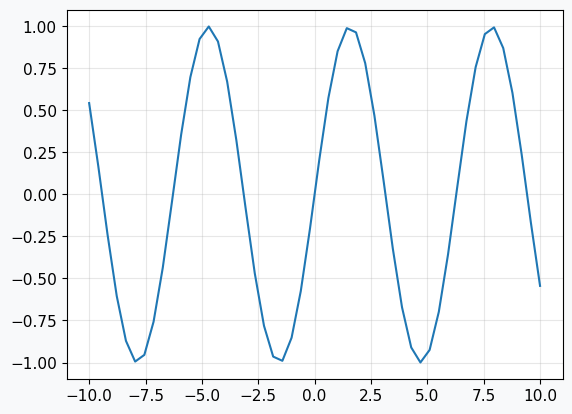

In [131]:
# Learn the simplest way to plot firts

x = np.linspace(-10,10)
y = np.sin(x)

plt.plot(x,y)
plt.show()

In [75]:
# adding decorations like axis labels, legend, colors, dotted curves or any form of curves all can be found in the link

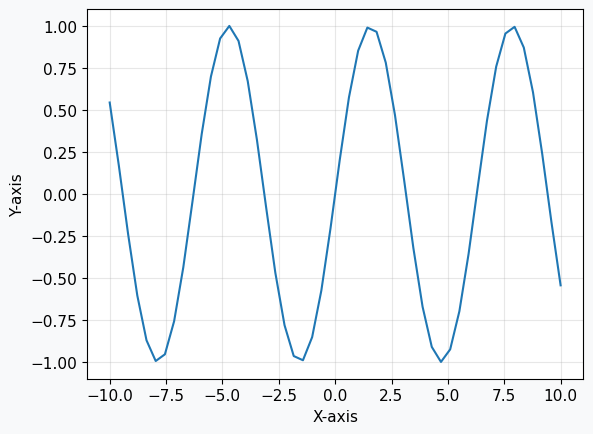

In [77]:
plt.plot(x,y)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show() # for clean figure

In [ ]:
# Defining shape, dimensions and resolution of the figure, very neccessary when you intend to include in your thesis

In [134]:
plt.figure?

Signature:
plt.figure(
    num: 'int | str | Figure | SubFigure | None' = None,
    figsize: 'tuple[float, float] | None' = None,
    dpi: 'float | None' = None,
    *,
    facecolor: 'ColorType | None' = None,
    edgecolor: 'ColorType | None' = None,
    frameon: 'bool' = True,
    FigureClass: 'type[Figure]' = <class 'matplotlib.figure.Figure'>,
    clear: 'bool' = False,
    **kwargs,
) -> 'Figure'
Docstring:
Create a new figure, or activate an existing figure.

Parameters
----------
num : int or str or `.Figure` or `.SubFigure`, optional
    A unique identifier for the figure.

    If a figure with that identifier already exists, this figure is made
    active and returned. An integer refers to the ``Figure.number``
    attribute, a string refers to the figure label.

    If there is no figure with the identifier or *num* is not given, a new
    figure is created, made active and returned.  If *num* is an int, it
    will be used for the ``Figure.number`` attribute, otherwise, an


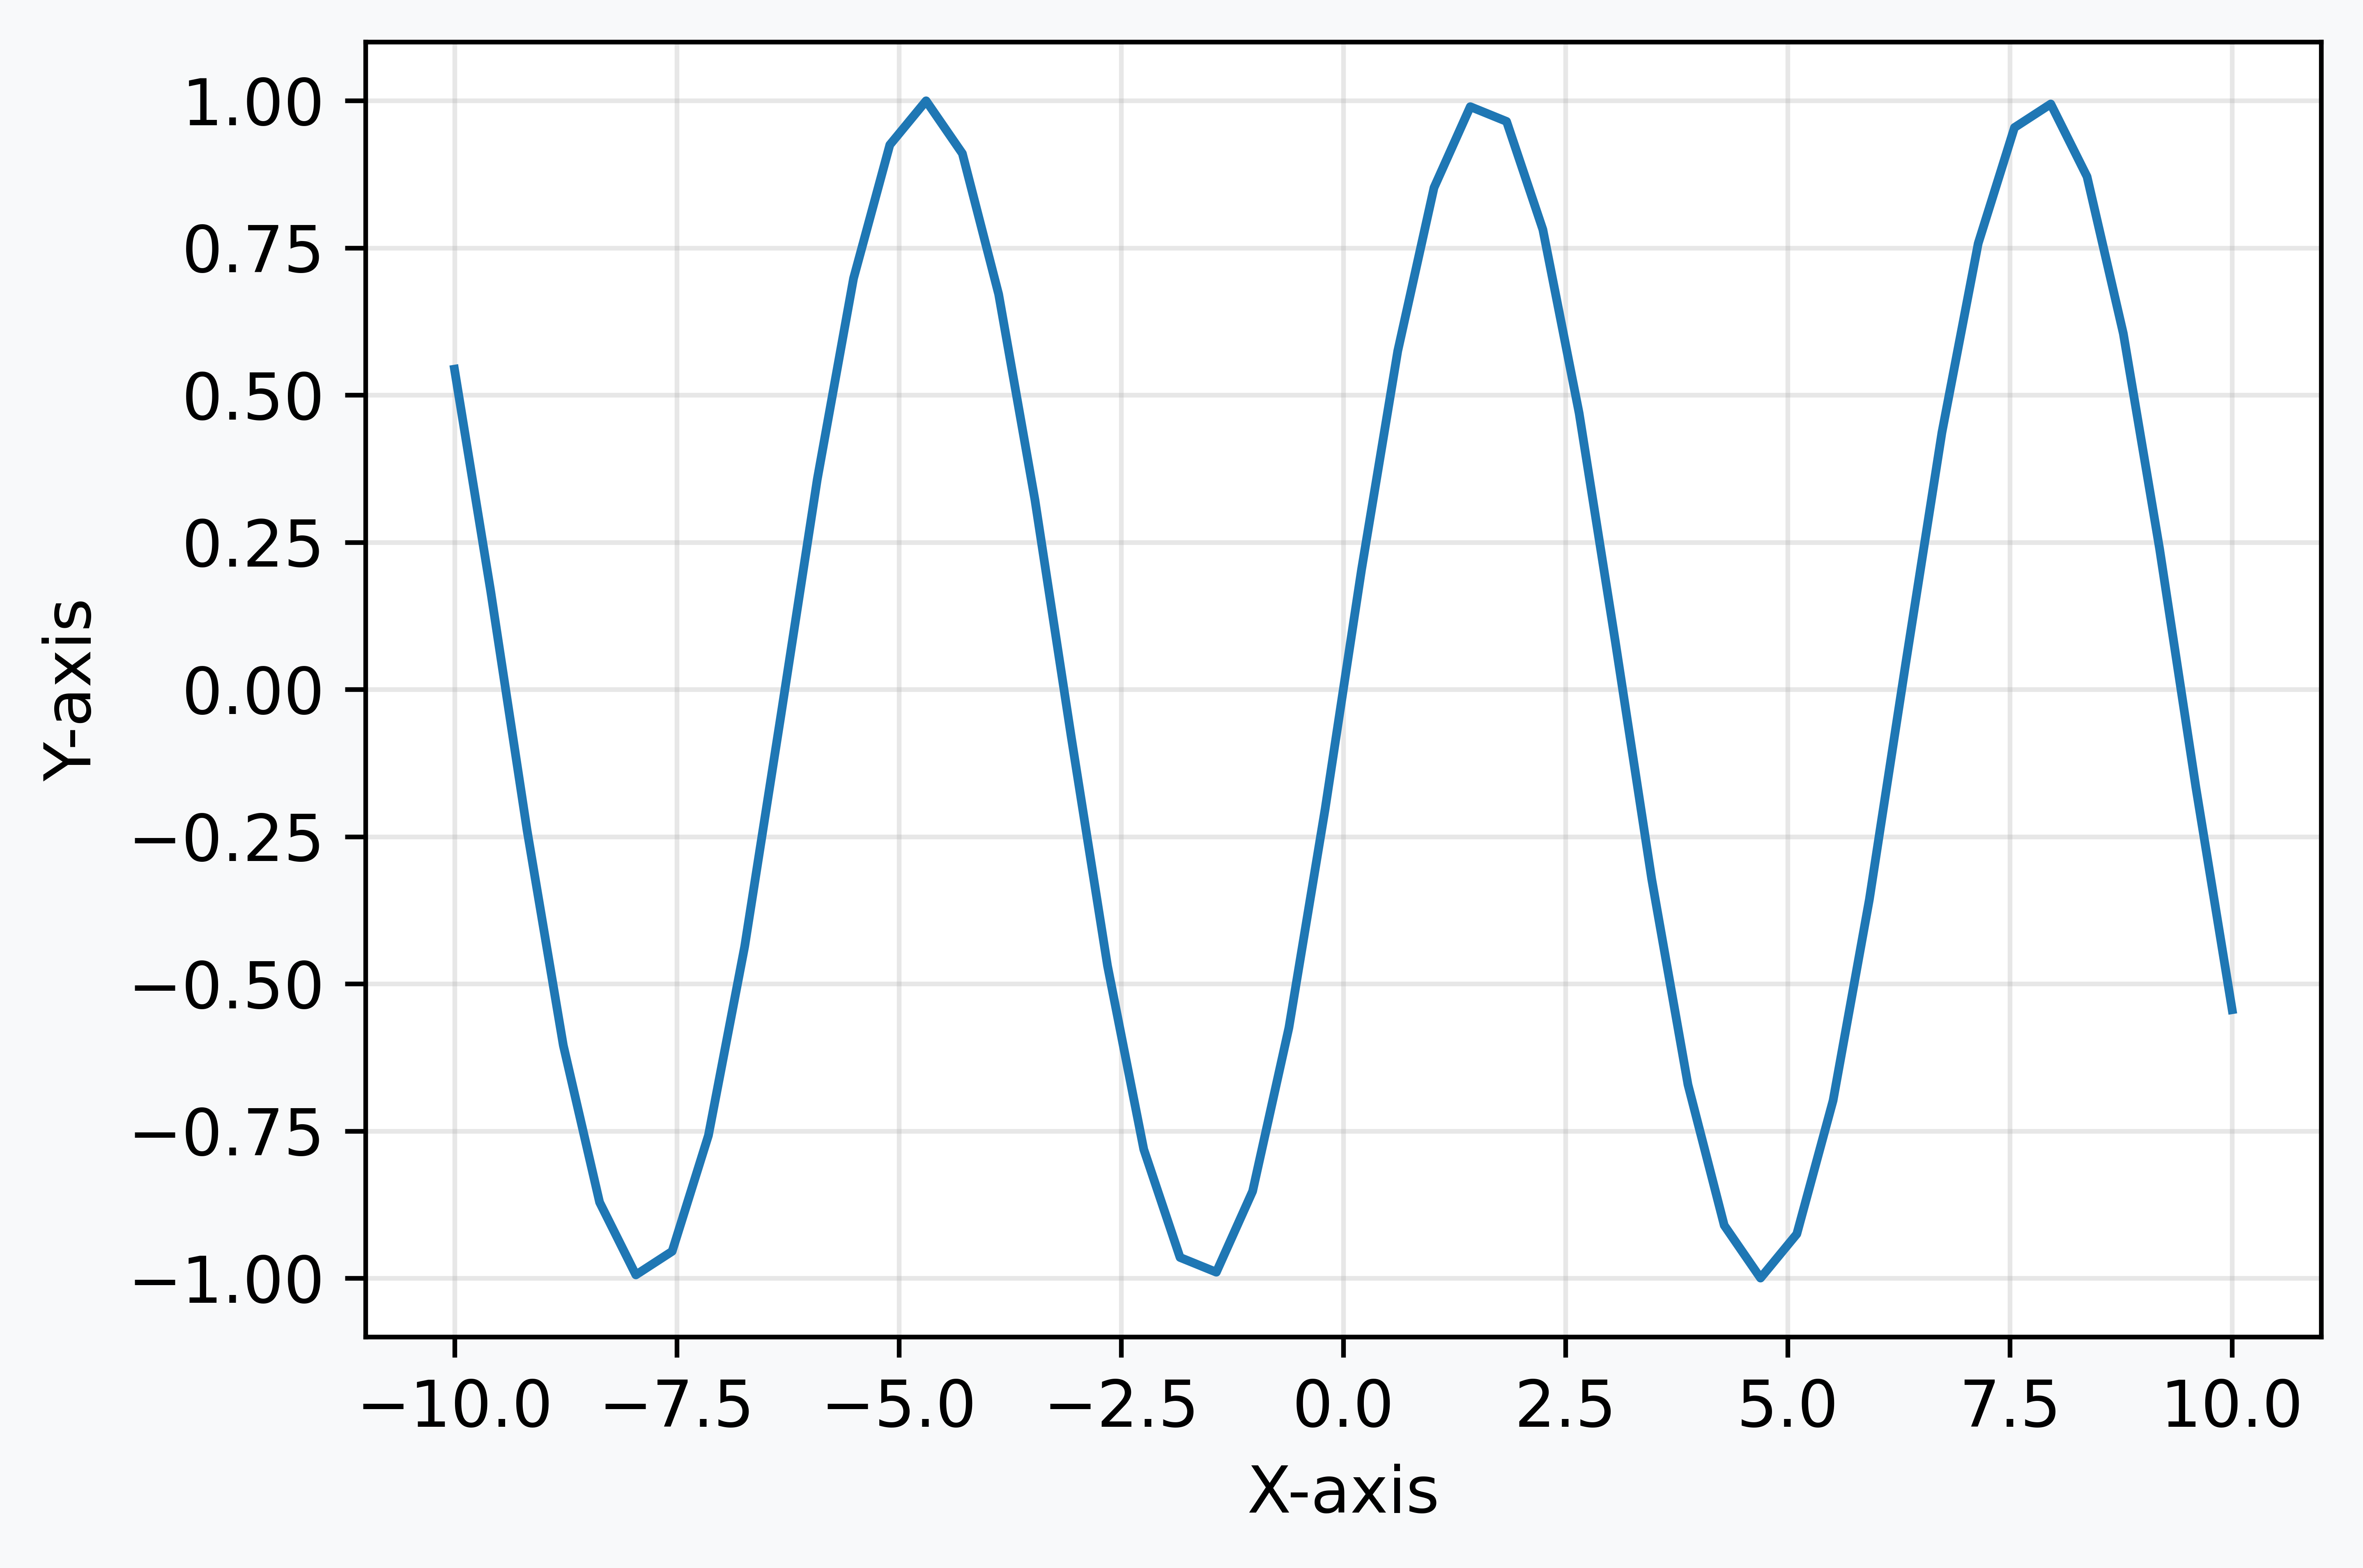

In [133]:
fig = plt.figure(figsize=(6, 4), dpi=1024)
ax = fig.add_subplot(111)  # create the axes

ax.plot(x, y)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")

plt.show()

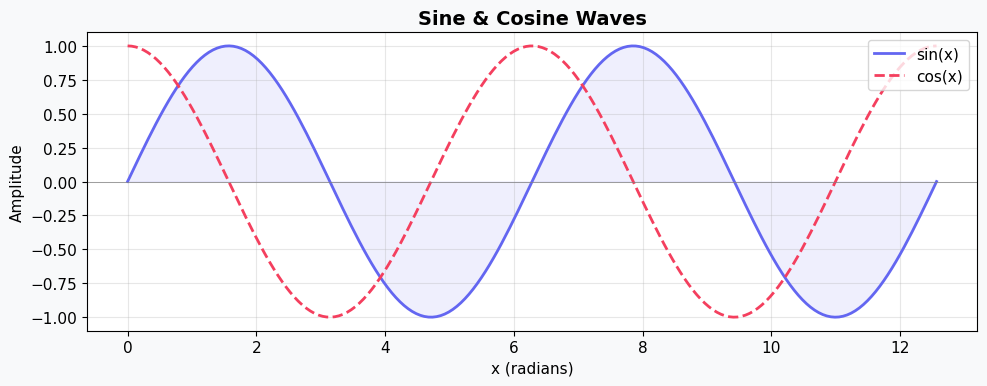

In [71]:
# Set a clean global style
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor': '#ffffff',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'figure.dpi': 100,
})

# --- Basic Line Plot ---
x = np.linspace(0, 4 * np.pi, 200)
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(x, np.sin(x), label='sin(x)', color='#6366f1', linewidth=2)
ax.plot(x, np.cos(x), label='cos(x)', color='#f43f5e', linewidth=2, linestyle='--')
ax.fill_between(x, np.sin(x), alpha=0.1, color='#6366f1')

ax.set_title('Sine & Cosine Waves', fontsize=14, fontweight='bold')
ax.set_xlabel('x (radians)')
ax.set_ylabel('Amplitude')
ax.legend(loc='upper right')
ax.axhline(y=0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

## 6.2 Subplots & Multiple Views

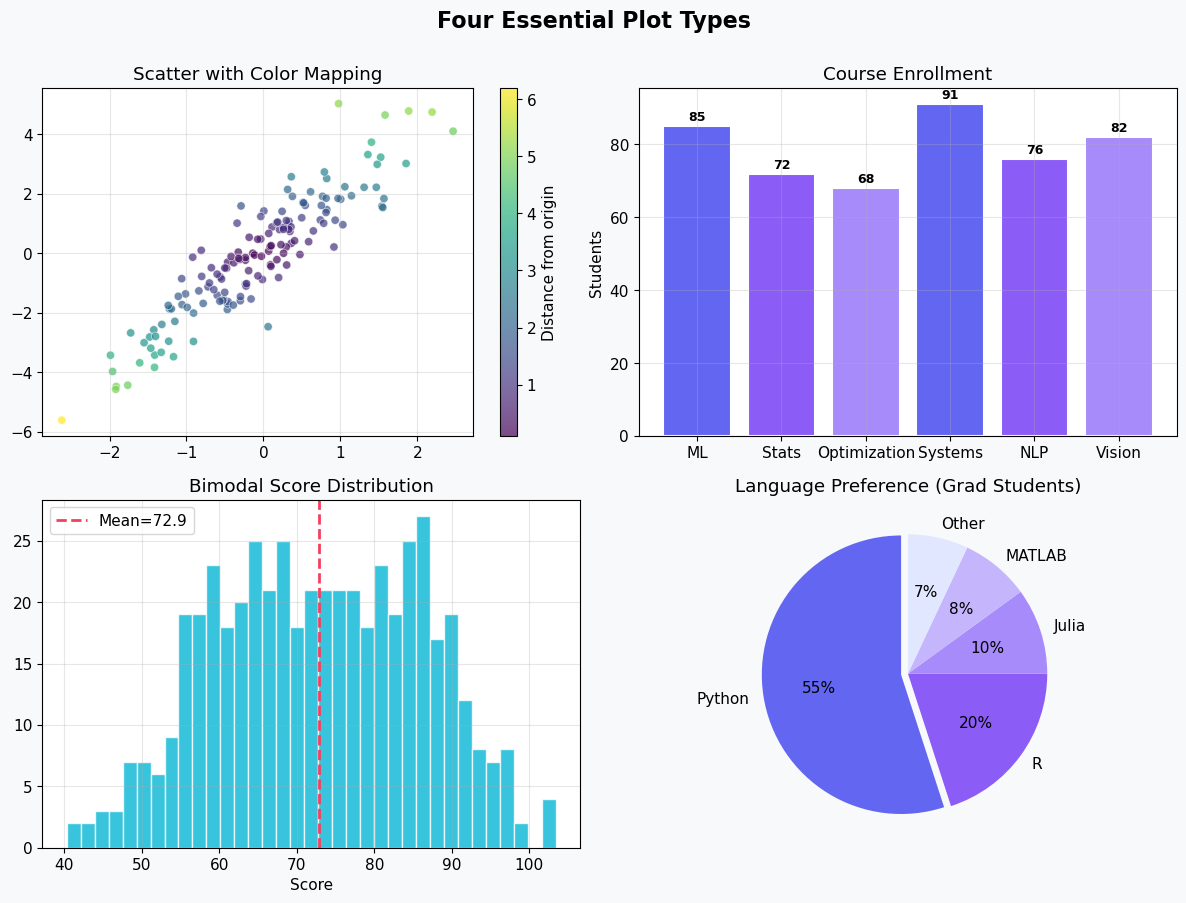

In [82]:
np.random.seed(42)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Four Essential Plot Types', fontsize=16, fontweight='bold', y=1.0)

# 1. Scatter plot with color mapping
n = 150
x = np.random.randn(n)
y = 2 * x + np.random.randn(n) * 0.8
colors = np.sqrt(x**2 + y**2)
scatter = axes[0, 0].scatter(x, y, c=colors, cmap='viridis', alpha=0.7, edgecolors='white', linewidth=0.5)
axes[0, 0].set_title('Scatter with Color Mapping')
plt.colorbar(scatter, ax=axes[0, 0], label='Distance from origin')

# 2. Bar chart
categories = ['ML', 'Stats', 'Optimization', 'Systems', 'NLP', 'Vision']
values = [85, 72, 68, 91, 76, 82]
colors_bar = ['#6366f1', '#8b5cf6', '#a78bfa', '#6366f1', '#8b5cf6', '#a78bfa']
bars = axes[0, 1].bar(categories, values, color=colors_bar, edgecolor='white', linewidth=1.5)
axes[0, 1].set_title('Course Enrollment')
axes[0, 1].set_ylabel('Students')
for bar, val in zip(bars, values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                     str(val), ha='center', fontweight='bold', fontsize=9)

# 3. Histogram
data = np.concatenate([np.random.normal(65, 10, 300), np.random.normal(85, 7, 200)])
axes[1, 0].hist(data, bins=35, color='#06b6d4', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(np.mean(data), color='#f43f5e', linestyle='--', linewidth=2, label=f'Mean={np.mean(data):.1f}')
axes[1, 0].set_title('Bimodal Score Distribution')
axes[1, 0].set_xlabel('Score')
axes[1, 0].legend()

# 4. Pie chart
labels = ['Python', 'R', 'Julia', 'MATLAB', 'Other']
sizes = [55, 20, 10, 8, 7]
explode = (0.05, 0, 0, 0, 0)
axes[1, 1].pie(sizes, explode=explode, labels=labels, autopct='%1.0f%%',
               startangle=90, colors=['#6366f1','#8b5cf6','#a78bfa','#c4b5fd','#e0e7ff'])
axes[1, 1].set_title('Language Preference (Grad Students)')

plt.tight_layout()
plt.show()

## 6.3 Seaborn For Statistical Visualization

In [83]:
help(np.clip)

Help on _ArrayFunctionDispatcher in module numpy:

clip(a, a_min, a_max, out=None, **kwargs)
    Clip (limit) the values in an array.
    
    Given an interval, values outside the interval are clipped to
    the interval edges.  For example, if an interval of ``[0, 1]``
    is specified, values smaller than 0 become 0, and values larger
    than 1 become 1.
    
    Equivalent to but faster than ``np.minimum(a_max, np.maximum(a, a_min))``.
    
    No check is performed to ensure ``a_min < a_max``.
    
    Parameters
    ----------
    a : array_like
        Array containing elements to clip.
    a_min, a_max : array_like or None
        Minimum and maximum value. If ``None``, clipping is not performed on
        the corresponding edge. Only one of `a_min` and `a_max` may be
        ``None``. Both are broadcast against `a`.
    out : ndarray, optional
        The results will be placed in this array. It may be the input
        array for in-place clipping.  `out` must be of the right

In [84]:
import seaborn as sns
import pandas as pd

# Create a realistic dataset
np.random.seed(42)
n_students = 200

df = pd.DataFrame({
    'study_hours': np.clip(np.random.normal(25, 10, n_students), 5, 60),
    'sleep_hours': np.clip(np.random.normal(7, 1.5, n_students), 3, 10),
    'exam_score': np.zeros(n_students),
    'department': np.random.choice(['Computer Science', 'Data Science', 'AI & Robotics'], n_students),
    'semester': np.random.choice(['Fall', 'Spring'], n_students)
})


In [85]:
# Score is correlated with study & sleep
df['exam_score'] = np.clip(
    40 + df['study_hours'] * 1.2 + df['sleep_hours'] * 3 + np.random.normal(0, 8, n_students),
    0, 100
).round(1)

In [87]:
df.head()

,study_hours,sleep_hours,exam_score,department,semester
0,29.967142,7.536681,80.3,AI & Robotics,Spring
1,23.617357,7.841177,100.0,AI & Robotics,Fall
2,31.476885,8.624577,100.0,Computer Science,Spring
3,40.230299,8.580703,100.0,Computer Science,Fall
4,22.658466,4.933496,74.9,AI & Robotics,Spring


### Get more on Seaborn here: https://seaborn.pydata.org/tutorial.html

## Plotting With SNS

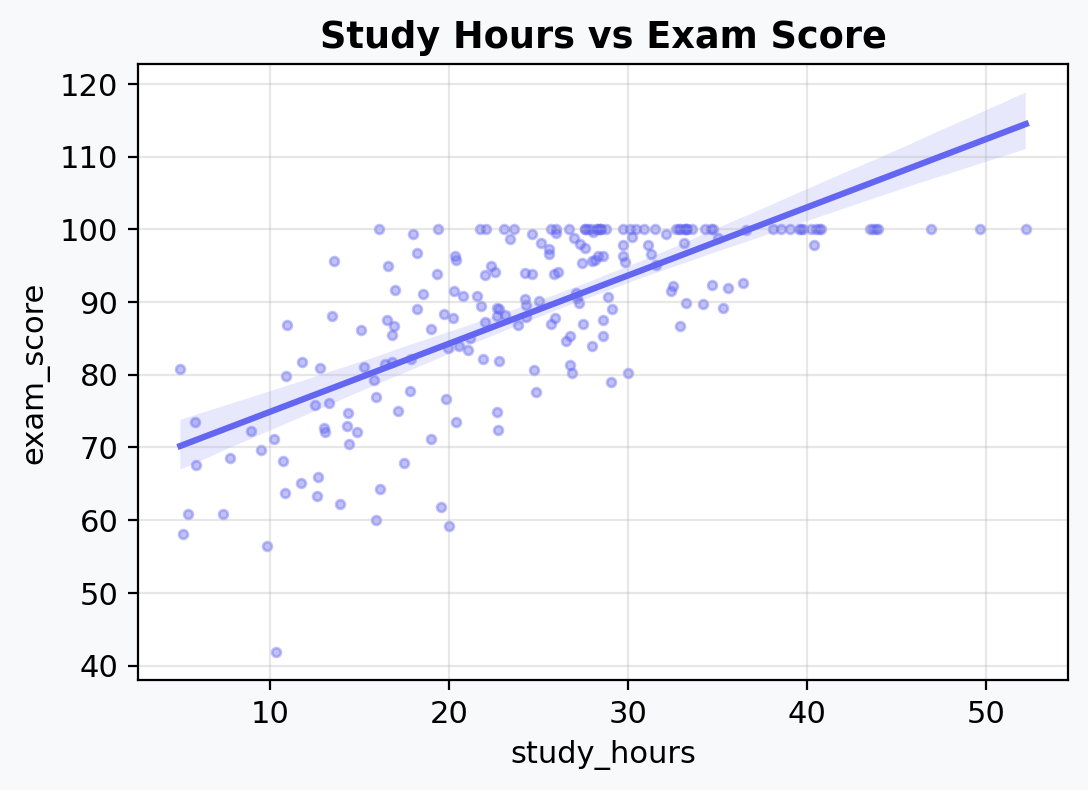

In [138]:
#plot  1. Regression plot: Study hours vs Exam score

fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

sns.regplot(data=df, x='study_hours', y='exam_score', ax=ax,
            scatter_kws={'alpha': 0.4, 's': 10}, color='#6366f1')
ax.set_title('Study Hours vs Exam Score', fontweight='bold')
plt.show()

In [94]:
sns.regplot?

Signature:
sns.regplot(
    data=None,
    *,
    x=None,
    y=None,
    x_estimator=None,
    x_bins=None,
    x_ci='ci',
    scatter=True,
    fit_reg=True,
    ci=95,
    n_boot=1000,
    units=None,
    seed=None,
    order=1,
    logistic=False,
    lowess=False,
    robust=False,
    logx=False,
    x_partial=None,
    y_partial=None,
    truncate=True,
    dropna=True,
    x_jitter=None,
    y_jitter=None,
    label=None,
    color=None,
    marker='o',
    scatter_kws=None,
    line_kws=None,
    ax=None,
)
Docstring:
Plot data and a linear regression model fit.

There are a number of mutually exclusive options for estimating the
regression model. See the :ref:`tutorial <regression_tutorial>` for more
information.    

Parameters
----------
x, y: string, series, or vector array
    Input variables. If strings, these should correspond with column names
    in ``data``. When pandas objects are used, axes will be labeled with
    the series name.
data : DataFrame
    Tidy ("long-

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

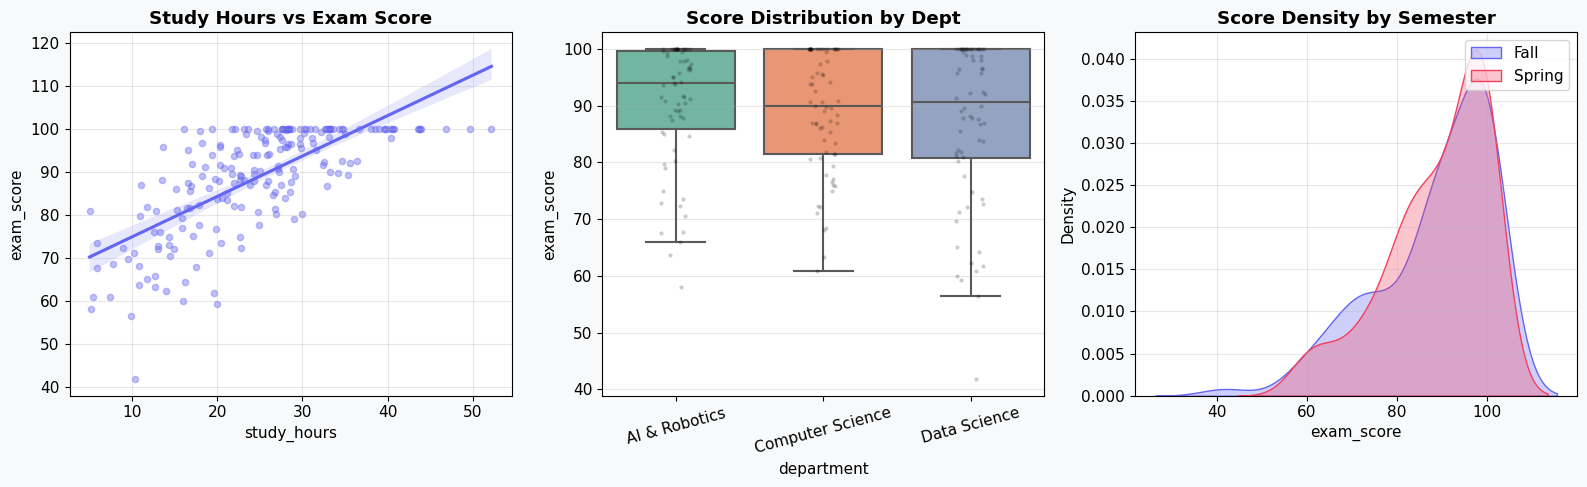

In [89]:
# --- Seaborn Statistical Plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Regression plot: Study hours vs Exam score
sns.regplot(data=df, x='study_hours', y='exam_score', ax=axes[0],
            scatter_kws={'alpha': 0.4, 's': 20}, color='#6366f1')
axes[0].set_title('Study Hours vs Exam Score', fontweight='bold')

# 2. Box + Strip plot by department
sns.boxplot(data=df, x='department', y='exam_score', ax=axes[1],
            palette='Set2', fliersize=0)
sns.stripplot(data=df, x='department', y='exam_score', ax=axes[1],
              color='black', alpha=0.2, size=3, jitter=True)
axes[1].set_title('Score Distribution by Dept', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

# 3. KDE (kernel density estimation) by semester
for sem, color in [('Fall', '#6366f1'), ('Spring', '#f43f5e')]:
    subset = df[df['semester'] == sem]['exam_score']
    sns.kdeplot(subset, ax=axes[2], fill=True, alpha=0.3, label=sem, color=color)
axes[2].set_title('Score Density by Semester', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

In [90]:
import warnings
warnings.filterwarnings("ignore")

## 6.4 Heatmaps & Correlation Matrices

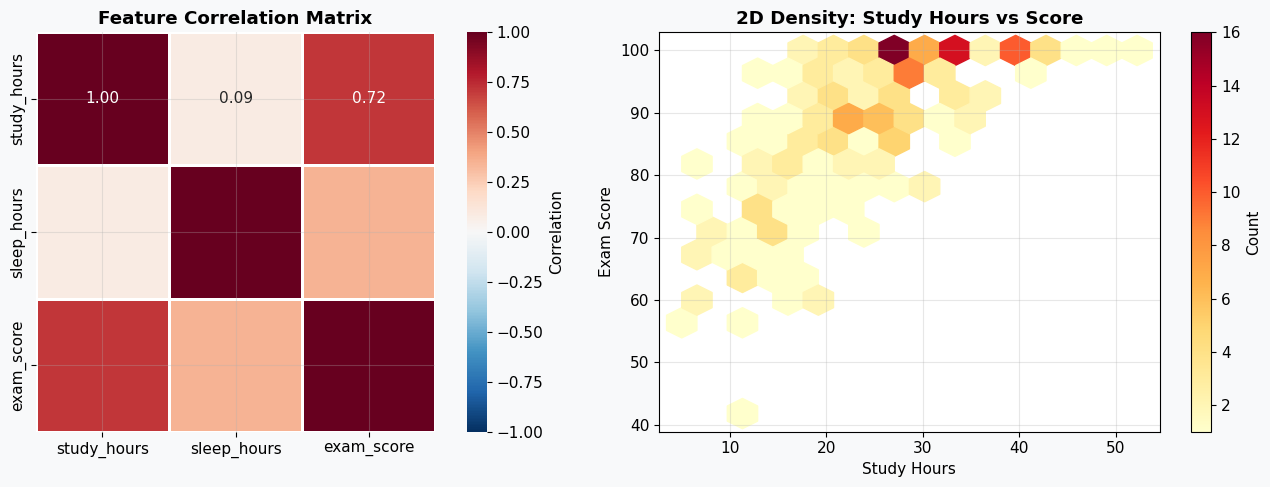

In [92]:
# Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation matrix
numeric_cols = ['study_hours', 'sleep_hours', 'exam_score']
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[0], square=True, linewidths=2, fmt='.2f',
            cbar_kws={'label': 'Correlation'})
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')

# 2D density / hexbin plot
hb = axes[1].hexbin(df['study_hours'], df['exam_score'], gridsize=15,
                     cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('Study Hours')
axes[1].set_ylabel('Exam Score')
axes[1].set_title('2D Density: Study Hours vs Score', fontweight='bold')
plt.colorbar(hb, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

## 6.5 Advanced: Animated Plot (Gradient Descent Visualization)

This animates how **gradient descent** finds the minimum of a function.

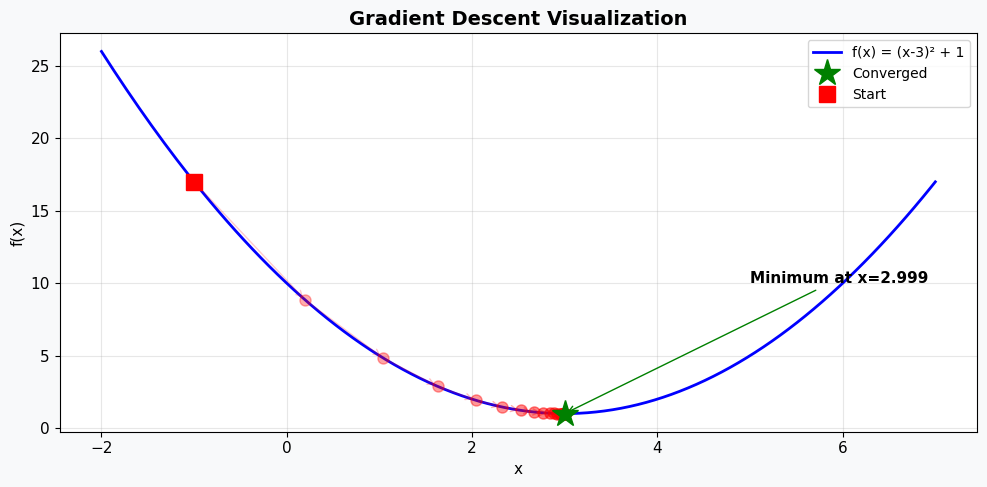


Gradient Descent Path:
  Start: x = -1.000, f(x) = 17.000
  End:   x = 2.999, f(x) = 1.000
  Steps: 25


In [101]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Function: f(x) = (x - 3)^2 + 1
def f(x):
    return (x - 3)**2 + 1

def df_dx(x):
    return 2 * (x - 3)

# Gradient descent
learning_rate = 0.15
x_start = -1.0
trajectory = [x_start]

x = x_start
for _ in range(25):
    x = x - learning_rate * df_dx(x)
    trajectory.append(x)

# Static version (animation may not work in all environments)
fig, ax = plt.subplots(figsize=(10, 5))
x_range = np.linspace(-2, 7, 200)
ax.plot(x_range, f(x_range), 'b-', linewidth=2, label='f(x) = (x-3)² + 1')

# Plot trajectory
for i in range(len(trajectory) - 1):
    alpha = 0.3 + 0.7 * (i / len(trajectory))
    ax.plot(trajectory[i], f(trajectory[i]), 'ro', markersize=8, alpha=alpha)
    ax.annotate('', xy=(trajectory[i+1], f(trajectory[i+1])),
                xytext=(trajectory[i], f(trajectory[i])),
                arrowprops=dict(arrowstyle='->', color='red', alpha=alpha*0.7))

ax.plot(trajectory[-1], f(trajectory[-1]), 'g*', markersize=20, label='Converged', zorder=5)
ax.plot(trajectory[0], f(trajectory[0]), 'rs', markersize=12, label='Start', zorder=5)

ax.set_title('Gradient Descent Visualization', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend(fontsize=10)
ax.annotate(f'Minimum at x={trajectory[-1]:.3f}', xy=(trajectory[-1], f(trajectory[-1])),
            xytext=(5, 10), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green'))
plt.tight_layout()
plt.show()

print(f"\nGradient Descent Path:")
print(f"  Start: x = {trajectory[0]:.3f}, f(x) = {f(trajectory[0]):.3f}")
print(f"  End:   x = {trajectory[-1]:.3f}, f(x) = {f(trajectory[-1]):.3f}")
print(f"  Steps: {len(trajectory) - 1}")

## 6.6 Advanced: 3D Surface Plot

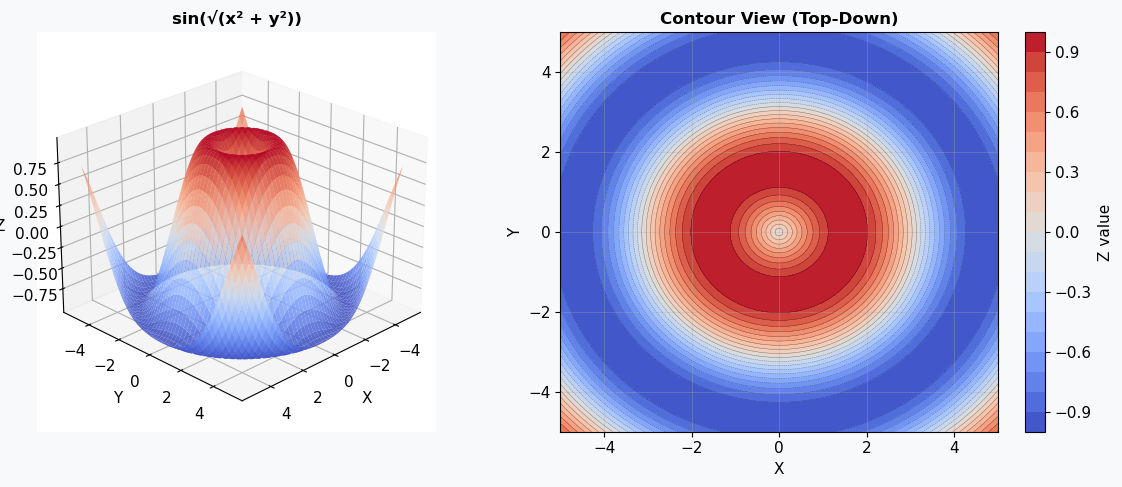

In [91]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

# 3D surface plot
ax1 = fig.add_subplot(121, projection='3d')
X = np.linspace(-5, 5, 100)
Y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(X, Y)
Z = np.sin(np.sqrt(X**2 + Y**2))

surf = ax1.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.85,
                         edgecolor='none', antialiased=True)
ax1.set_title('sin(√(x² + y²))', fontsize=12, fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.view_init(elev=25, azim=45)

# 3D contour (below the surface)
ax2 = fig.add_subplot(122)
Z2 = np.sin(np.sqrt(X**2 + Y**2))
contour = ax2.contourf(X, Y, Z2, levels=20, cmap='coolwarm')
ax2.contour(X, Y, Z2, levels=20, colors='black', linewidths=0.3, alpha=0.5)
plt.colorbar(contour, ax=ax2, label='Z value')
ax2.set_title('Contour View (Top-Down)', fontsize=12, fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

plt.tight_layout()
plt.show()

---
### 🧪 Trial 4: Visualize Recursion Depth

Create a **bar chart** that compares the **execution time** of `fib_naive`, `fib_memo`, and `fib_iter` for `n = 10, 15, 20, 25, 30`. Use a **log scale** on the y-axis.

> 💡 Hint: Use `time.perf_counter()` to measure, and `ax.set_yscale('log')` for log scale.

**Try it yourself below, then check the solution.**

In [ ]:
# ✏️ YOUR CODE HERE
# Measure times for fib_naive, fib_memo, fib_iter at n = 10, 15, 20, 25, 30
# Create a grouped bar chart with log scale

<details>
<summary>🔓 <b>Click to reveal solution</b></summary>

```python
import time
import numpy as np
import matplotlib.pyplot as plt
from functools import lru_cache

def fib_naive(n):
    if n <= 1: return n
    return fib_naive(n-1) + fib_naive(n-2)

@lru_cache(maxsize=None)
def fib_memo(n):
    if n <= 1: return n
    return fib_memo(n-1) + fib_memo(n-2)

def fib_iter(n):
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a

ns = [10, 15, 20, 25, 30]
times = {'Naive': [], 'Memoized': [], 'Iterative': []}

for n in ns:
    for name, func in [('Naive', fib_naive), ('Memoized', fib_memo), ('Iterative', fib_iter)]:
        fib_memo.cache_clear()  # Reset memo cache for fair comparison
        start = time.perf_counter()
        func(n)
        times[name].append(time.perf_counter() - start)

x = np.arange(len(ns))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, times['Naive'],     width, label='Naive O(2ⁿ)',    color='#ef4444')
ax.bar(x,         times['Memoized'],  width, label='Memoized O(n)',   color='#6366f1')
ax.bar(x + width, times['Iterative'], width, label='Iterative O(n)',  color='#22c55e')

ax.set_yscale('log')
ax.set_xlabel('n')
ax.set_ylabel('Time (seconds, log scale)')
ax.set_title('Fibonacci: Naive vs Memoized vs Iterative', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ns)
ax.legend()
plt.tight_layout()
plt.show()
```

</details>

---
# Module 7: Capstone Challenges 🏆

These combine multiple concepts from the workshop. Attempt at least one!

---

### 🧪 Challenge A: LRU Cache from Scratch

Implement your own `LRUCache` class with:
- `get(key)` → return value or -1
- `put(key, value)` → insert/update, evicting the least recently used item if at capacity
- Use `OrderedDict` or a doubly-linked list + dict

```python
cache = LRUCache(capacity=3)
cache.put("a", 1)
cache.put("b", 2)
cache.put("c", 3)
cache.get("a")        # Returns 1 (moves "a" to most recent)
cache.put("d", 4)     # Evicts "b" (least recently used)
print(cache.get("b")) # Returns -1 (was evicted)
```

In [ ]:
# ✏️ YOUR CODE HERE
class LRUCache:
    pass

<details>
<summary>🔓 <b>Click to reveal solution</b></summary>

```python
from collections import OrderedDict

class LRUCache:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self._cache = OrderedDict()
    
    def get(self, key):
        if key not in self._cache:
            return -1
        self._cache.move_to_end(key)  # Mark as recently used
        return self._cache[key]
    
    def put(self, key, value):
        if key in self._cache:
            self._cache.move_to_end(key)
        self._cache[key] = value
        if len(self._cache) > self.capacity:
            evicted = self._cache.popitem(last=False)  # Remove oldest
            print(f"  🗑️ Evicted: {evicted}")
    
    def __repr__(self):
        return f"LRUCache({dict(self._cache)})"

# Test
cache = LRUCache(capacity=3)
cache.put("a", 1)
cache.put("b", 2)
cache.put("c", 3)
print(cache)
cache.get("a")         # Moves "a" to most recent
cache.put("d", 4)      # Evicts "b"
print(f"get('b') = {cache.get('b')}")  # -1
print(cache)
```

</details>

---

### 🧪 Challenge B: Recursive Fractal Tree Visualization

Draw a **fractal tree** using recursion and Matplotlib. Each branch splits into two shorter branches at an angle.

In [ ]:
# ✏️ YOUR CODE HERE
# def draw_tree(ax, x, y, angle, length, depth): ...
# Hint: use ax.plot() for each branch, and recurse for left & right sub-branches

<details>
<summary>🔓 <b>Click to reveal solution</b></summary>

```python
import matplotlib.pyplot as plt
import numpy as np

def draw_tree(ax, x, y, angle, length, depth, max_depth):
    if depth > max_depth or length < 1:
        return
    
    # Calculate endpoint
    x_end = x + length * np.cos(np.radians(angle))
    y_end = y + length * np.sin(np.radians(angle))
    
    # Color: brown trunk → green leaves
    t = depth / max_depth
    color = (0.36 * (1-t) + 0.18 * t,   # R
             0.25 * (1-t) + 0.65 * t,    # G
             0.20 * (1-t) + 0.25 * t)    # B
    
    linewidth = max(1, (max_depth - depth) * 1.5)
    ax.plot([x, x_end], [y, y_end], color=color, linewidth=linewidth, solid_capstyle='round')
    
    # Recurse: left and right branches
    new_length = length * 0.72
    draw_tree(ax, x_end, y_end, angle + 25, new_length, depth + 1, max_depth)
    draw_tree(ax, x_end, y_end, angle - 25, new_length, depth + 1, max_depth)

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')
ax.axis('off')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

draw_tree(ax, 0, 0, 90, 80, 0, max_depth=10)
ax.set_title('Recursive Fractal Tree', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
```

</details>

---

### 🧪 Challenge C: CLI Data Dashboard

Combine **classes**, **decorators**, and **matplotlib** to build a mini analytics dashboard:

1. Create a `@validate_data` decorator that checks if input is a non-empty list of numbers
2. Create a `DataAnalyzer` class with methods: `summary()`, `plot_distribution()`, `detect_outliers()` (using IQR method)
3. Plot results using subplots

In [ ]:
# ✏️ YOUR CODE HERE

<details>
<summary>🔓 <b>Click to reveal solution</b></summary>

```python
import numpy as np
import matplotlib.pyplot as plt
import functools

def validate_data(func):
    @functools.wraps(func)
    def wrapper(self, *args, **kwargs):
        if not hasattr(self, 'data') or len(self.data) == 0:
            raise ValueError("No data loaded!")
        if not all(isinstance(x, (int, float)) for x in self.data):
            raise TypeError("All data must be numeric")
        return func(self, *args, **kwargs)
    return wrapper

class DataAnalyzer:
    def __init__(self, data: list):
        self.data = np.array(data, dtype=float)
    
    @validate_data
    def summary(self) -> dict:
        return {
            'count': len(self.data),
            'mean': np.mean(self.data),
            'median': np.median(self.data),
            'std': np.std(self.data),
            'min': np.min(self.data),
            'max': np.max(self.data),
        }
    
    @validate_data
    def detect_outliers(self) -> np.ndarray:
        q1, q3 = np.percentile(self.data, [25, 75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        return self.data[(self.data < lower) | (self.data > upper)]
    
    @validate_data
    def dashboard(self):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # Histogram
        axes[0].hist(self.data, bins=25, color='#6366f1', edgecolor='white', alpha=0.8)
        axes[0].axvline(np.mean(self.data), color='red', linestyle='--', label=f'Mean={np.mean(self.data):.1f}')
        axes[0].set_title('Distribution')
        axes[0].legend()
        
        # Box plot with outliers
        axes[1].boxplot(self.data, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#a78bfa'))
        outliers = self.detect_outliers()
        axes[1].set_title(f'Box Plot ({len(outliers)} outliers)')
        
        # QQ plot (rough)
        sorted_data = np.sort(self.data)
        theoretical = np.random.normal(np.mean(self.data), np.std(self.data), len(self.data))
        theoretical.sort()
        axes[2].scatter(theoretical, sorted_data, alpha=0.5, s=15, color='#6366f1')
        lims = [min(theoretical.min(), sorted_data.min()), max(theoretical.max(), sorted_data.max())]
        axes[2].plot(lims, lims, 'r--', linewidth=1)
        axes[2].set_title('Q-Q Plot')
        axes[2].set_xlabel('Theoretical')
        axes[2].set_ylabel('Observed')
        
        plt.suptitle('Data Analyzer Dashboard', fontweight='bold', fontsize=14)
        plt.tight_layout()
        plt.show()

# Test with some data including outliers
np.random.seed(42)
test_data = list(np.random.normal(50, 10, 200)) + [120, -15, 110]
analyzer = DataAnalyzer(test_data)

stats = analyzer.summary()
for k, v in stats.items():
    print(f"  {k:>8s}: {v:.2f}")

print(f"  Outliers: {analyzer.detect_outliers()}")
analyzer.dashboard()
```

</details>

---
# 🎓 Workshop Wrap-Up

## What We Covered

| Module | Key Takeaways |
|--------|--------------|
| **Functions** | First-class objects, closures, `*args`/`**kwargs`, type hints |
| **Classes & OOP** | Encapsulation, inheritance, dunder methods, dataclasses |
| **Abstraction** | ABCs, protocols, designing interfaces |
| **Recursion** | Base cases, memoization, real-world recursive patterns |
| **Decorators & Generators** | `@decorator` pattern, `yield`, lazy evaluation |
| **Visualization** | Matplotlib, Seaborn, 3D plots, gradient descent animation |

## Recommended Resources

- 📖 **Fluent Python** by Luciano Ramalho — deep dive into Pythonic patterns
- 📖 **Python Cookbook** by David Beazley — practical recipes
- 🌐 **Real Python** (realpython.com) — tutorials for all levels
- 🌐 **Matplotlib Gallery** (matplotlib.org/stable/gallery) — copy-paste plot examples
- 🏋️ **LeetCode / HackerRank** — practice recursion and data structures

## Next Steps

1. Re-run this notebook and **complete all the trial questions**
2. Modify the examples — break things, fix them, extend them
3. Pick one capstone challenge and build a polished solution
4. Bring questions to the next session!

> *"The best way to learn to code is to code."* — Happy hacking! 🐍✨